# Mining Street Vendor Transaction Patterns to Predict Daily Revenue
## Data Mining Project — CT23A135

| Field | Details |
|---|---|
| **Student** | NYUYDZE BANVEN ERIC JUNIOR |
| **Matricule** | CT23A135 |
| **Supervisor** | Mr. Kometa Denis |
| **Programme** | B.Sc. Computer Science |
| **Course** | Data Mining & Knowledge Discovery |
| **Date** | April 2026 |

---
### How to run
**Run Cell 1 first (installs + imports everything), then run cells in order.**  
All subsequent cells depend on the variables defined in Cell 1.


In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 1 — INSTALL PACKAGES + ALL IMPORTS + GLOBAL CONFIG        ║
# ║  ▶ Run this cell FIRST before any other cell                     ║
# ╚══════════════════════════════════════════════════════════════════╝

# ── 1a. Install any missing packages automatically ─────────────────
import subprocess, sys

REQUIRED = [
    "numpy", "pandas", "matplotlib", "seaborn",
    "scikit-learn", "mlxtend"
]
for pkg in REQUIRED:
    try:
        __import__(pkg if pkg != "scikit-learn" else "sklearn")
    except ImportError:
        print(f"Installing {pkg} …")
        subprocess.check_call([sys.executable, "-m", "pip", "install",
                               pkg, "--quiet"])

# ── 1b. Standard library ───────────────────────────────────────────
import os
import random
import json
import time
import warnings
warnings.filterwarnings("ignore")

# ── 1c. Numerical computing ────────────────────────────────────────
import numpy as np
import pandas as pd

# ── 1d. Visualisation ──────────────────────────────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# ── 1e. Scikit-learn — preprocessing ──────────────────────────────
from sklearn.preprocessing import LabelEncoder, StandardScaler

# ── 1f. Scikit-learn — model selection & evaluation ───────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score,
)

# ── 1g. Scikit-learn — clustering ─────────────────────────────────
from sklearn.cluster import KMeans

# ── 1h. Scikit-learn — regression algorithms ──────────────────────
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)

# ── 1i. Association rule mining ────────────────────────────────────
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

# ── 1j. Global plot style ──────────────────────────────────────────
PALETTE  = ["#1B4F72","#2E86AB","#A23B72","#F18F01","#C73E1D",
            "#3B1F2B","#44BBA4","#E94F37","#393E41","#F5A623"]
BG_COLOR = "#F7F9FC"

plt.rcParams.update({
    "figure.facecolor" : BG_COLOR,
    "axes.facecolor"   : BG_COLOR,
    "axes.grid"        : True,
    "grid.color"       : "#DDE3EC",
    "font.family"      : "DejaVu Sans",
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

# ── 1k. Reproducibility ────────────────────────────────────────────
np.random.seed(42)
random.seed(42)

# ── 1l. Dataset constants (used in every phase) ────────────────────
CITY_MARKETS = {
    "Buea": {
        "markets"      : ["Mile 17 Motor Park Market",
                          "Molyko Market", "Sandpit Market"],
        "base_revenue" : 18_000,
        "n_vendors"    : 12,
    },
    "Yaoundé": {
        "markets"      : ["Marché Mokolo", "Marché du Mfoundi",
                          "Marché Essos", "Marché Mvog-Mbi"],
        "base_revenue" : 32_000,
        "n_vendors"    : 14,
    },
    "Douala": {
        "markets"      : ["Marché Central (New Bell)", "Marché Sandaga",
                          "Marché Nkoulouloun", "Marché Deido",
                          "Marché Congo"],
        "base_revenue" : 42_000,
        "n_vendors"    : 14,
    },
}

PRODUCT_CATEGORIES = [
    "Plantain & Cassava",
    "Fresh Vegetables",
    "Dried Fish & Crayfish",
    "Palm Oil & Condiments",
    "Fruits (Mango/Avocado/Pineapple)",
    "Second-Hand Clothing (Friperie)",
    "Mobile Phone Accessories",
    "Cosmetics & Hair Products",
    "Cooked Street Food (Soya/Beignets)",
    "Charcoal & Firewood",
]

CATEGORY_MULTIPLIER = {
    "Plantain & Cassava"               : 0.85,
    "Fresh Vegetables"                 : 0.90,
    "Dried Fish & Crayfish"            : 1.10,
    "Palm Oil & Condiments"            : 0.95,
    "Fruits (Mango/Avocado/Pineapple)" : 1.00,
    "Second-Hand Clothing (Friperie)"  : 1.35,
    "Mobile Phone Accessories"         : 1.40,
    "Cosmetics & Hair Products"        : 1.25,
    "Cooked Street Food (Soya/Beignets)": 1.15,
    "Charcoal & Firewood"              : 0.80,
}

CAMEROON_HOLIDAYS = {
    (1,  1): "New Year",
    (2, 11): "Youth Day",
    (3,  8): "Women's Day",
    (5,  1): "Labour Day",
    (5, 20): "National Day",
    (8, 15): "Assumption",
    (12,25): "Christmas",
}

DAY_MULTIPLIER = {
    0: 0.78,   # Monday
    1: 0.82,   # Tuesday
    2: 0.85,   # Wednesday
    3: 0.90,   # Thursday
    4: 1.10,   # Friday
    5: 1.35,   # Saturday — peak
    6: 1.05,   # Sunday
}

DOW_ORDER   = ["Monday","Tuesday","Wednesday","Thursday",
               "Friday","Saturday","Sunday"]
MONTH_ORDER = ["September","October","November","December",
               "January","February","March"]

# ── Verify ─────────────────────────────────────────────────────────
print("=" * 55)
print("  All packages imported and config loaded ✔")
print(f"  numpy   {np.__version__}")
print(f"  pandas  {pd.__version__}")
print(f"  matplotlib  {matplotlib.__version__}")
print(f"  seaborn {sns.__version__}")
import sklearn, mlxtend
print(f"  scikit-learn  {sklearn.__version__}")
print(f"  mlxtend  {mlxtend.__version__}")
print("=" * 55)


  All packages imported and config loaded ✔
  numpy   2.4.4
  pandas  2.3.3
  matplotlib  3.10.9
  seaborn 0.13.2
  scikit-learn  1.8.0
  mlxtend  0.24.0


## Phase 1 — Dataset Generation

Synthetic dataset for 40 vendors across 12 Cameroonian markets, Sep 2025–Mar 2026. Revenue in CFA Francs (XAF).

In [2]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 2 — GENERATE VENDOR PROFILES                              ║
# ╚══════════════════════════════════════════════════════════════════╝

vendors_list = []
vendor_id    = 1

for city, cfg in CITY_MARKETS.items():
    for _ in range(cfg["n_vendors"]):

        market       = random.choice(cfg["markets"])
        category     = random.choice(PRODUCT_CATEGORIES)
        exp_years    = np.random.randint(2, 16)
        vendor_scale = np.clip(
            0.75 + 0.025 * exp_years + np.random.normal(0, 0.08),
            0.60, 1.45
        )

        vendors_list.append({
            "vendor_id"       : f"V{vendor_id:03d}",
            "city"            : city,
            "market"          : market,
            "product_category": category,
            "exp_years"       : exp_years,
            "vendor_scale"    : round(float(vendor_scale), 4),
            "base_revenue"    : cfg["base_revenue"],
        })
        vendor_id += 1

vendors_df = pd.DataFrame(vendors_list)
print(f"Vendor profiles created: {len(vendors_df)}")
print()
print(vendors_df[["vendor_id","city","market",
                  "product_category","exp_years"]].to_string(index=False))


Vendor profiles created: 40

vendor_id    city                    market                   product_category  exp_years
     V001    Buea            Sandpit Market                   Fresh Vegetables          8
     V002    Buea Mile 17 Motor Park Market   Fruits (Mango/Avocado/Pineapple)          9
     V003    Buea Mile 17 Motor Park Market              Palm Oil & Condiments         14
     V004    Buea Mile 17 Motor Park Market                   Fresh Vegetables          8
     V005    Buea            Sandpit Market Cooked Street Food (Soya/Beignets)         12
     V006    Buea Mile 17 Motor Park Market                Charcoal & Firewood          9
     V007    Buea             Molyko Market                 Plantain & Cassava          9
     V008    Buea Mile 17 Motor Park Market                   Fresh Vegetables          9
     V009    Buea Mile 17 Motor Park Market              Palm Oil & Condiments         13
     V010    Buea            Sandpit Market                Charcoal & F

In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 3 — GENERATE DAILY TRANSACTION RECORDS                    ║
# ╚══════════════════════════════════════════════════════════════════╝

date_range = pd.date_range("2025-09-01", "2026-03-31", freq="D")
records    = []

for _, vendor in vendors_df.iterrows():
    for date in date_range:

        dow   = date.dayofweek
        month = date.month

        # Rainy season effect (May–Oct)
        rain_season = 1 if month in [5,6,7,8,9,10] else 0
        rain_effect = 0.88 if (rain_season and np.random.rand() < 0.40) else 1.0

        # National holiday
        is_holiday     = 1 if (date.month, date.day) in CAMEROON_HOLIDAYS else 0
        holiday_effect = 1.25 if is_holiday else 1.0

        # Bi-weekly big market day (1st & 3rd Saturday)
        week_of_month  = (date.day - 1) // 7 + 1
        is_big_market  = 1 if (dow == 5 and week_of_month in [1, 3]) else 0
        big_mkt_effect = 1.18 if is_big_market else 1.0

        # Payday period (last 3 days of month)
        days_in_month    = pd.Period(date, "M").days_in_month
        is_payday_period = 1 if date.day >= days_in_month - 2 else 0
        payday_effect    = 1.15 if is_payday_period else 1.0

        # Daily revenue
        cat_mult = CATEGORY_MULTIPLIER[vendor["product_category"]]
        base     = vendor["base_revenue"] * vendor["vendor_scale"] * cat_mult

        revenue = (
            base
            * DAY_MULTIPLIER[dow]
            * rain_effect
            * holiday_effect
            * big_mkt_effect
            * payday_effect
            * np.random.lognormal(0, 0.18)
        )

        n_tx       = max(3, int(revenue / 1_800 + np.random.normal(0, 2)))
        avg_tx_val = round(revenue / n_tx, 0)

        records.append({
            "date"                     : date,
            "vendor_id"                : vendor["vendor_id"],
            "city"                     : vendor["city"],
            "market"                   : vendor["market"],
            "product_category"         : vendor["product_category"],
            "day_of_week"              : date.day_name(),
            "month"                    : date.strftime("%B"),
            "month_num"                : month,
            "is_weekend"               : 1 if dow >= 5 else 0,
            "is_holiday"               : is_holiday,
            "rain_season"              : rain_season,
            "is_big_market_day"        : is_big_market,
            "is_payday_period"         : is_payday_period,
            "n_transactions"           : n_tx,
            "avg_transaction_value_xaf": avg_tx_val,
            "daily_revenue_xaf"        : round(revenue, 0),
        })

df = pd.DataFrame(records)
df.to_csv("cameroon_vendor_data.csv", index=False)

print(f"Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range    : {df.date.min().date()}  →  {df.date.max().date()}")
print(f"Revenue range : {df.daily_revenue_xaf.min():,.0f}  –  "
      f"{df.daily_revenue_xaf.max():,.0f}  XAF")
print()
print(df.head(3).to_string())
print()
print("Saved → cameroon_vendor_data.csv ✔")


Dataset shape : 8,480 rows × 16 columns
Date range    : 2025-09-01  →  2026-03-31
Revenue range : 6,216  –  122,750  XAF

        date vendor_id  city          market  product_category day_of_week      month  month_num  is_weekend  is_holiday  rain_season  is_big_market_day  is_payday_period  n_transactions  avg_transaction_value_xaf  daily_revenue_xaf
0 2025-09-01      V001  Buea  Sandpit Market  Fresh Vegetables      Monday  September          9           0           0            1                  0                 0               7                     1528.0            10693.0
1 2025-09-02      V001  Buea  Sandpit Market  Fresh Vegetables     Tuesday  September          9           0           0            1                  0                 0               4                     2564.0            10258.0
2 2025-09-03      V001  Buea  Sandpit Market  Fresh Vegetables   Wednesday  September          9           0           0            1                  0                 0         

In [4]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — LOAD DATASET FROM CSV                                 ║
# ║  Run this instead of Cells 2-3 if the CSV already exists        ║
# ╚══════════════════════════════════════════════════════════════════╝

df = pd.read_csv("cameroon_vendor_data.csv", parse_dates=["date"])

print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")
print()
print(df.head(3).to_string())


Loaded: 8,480 rows × 16 columns
Columns: ['date', 'vendor_id', 'city', 'market', 'product_category', 'day_of_week', 'month', 'month_num', 'is_weekend', 'is_holiday', 'rain_season', 'is_big_market_day', 'is_payday_period', 'n_transactions', 'avg_transaction_value_xaf', 'daily_revenue_xaf']

        date vendor_id  city          market  product_category day_of_week      month  month_num  is_weekend  is_holiday  rain_season  is_big_market_day  is_payday_period  n_transactions  avg_transaction_value_xaf  daily_revenue_xaf
0 2025-09-01      V001  Buea  Sandpit Market  Fresh Vegetables      Monday  September          9           0           0            1                  0                 0               7                     1528.0            10693.0
1 2025-09-02      V001  Buea  Sandpit Market  Fresh Vegetables     Tuesday  September          9           0           0            1                  0                 0               4                     2564.0            10258.0
2 2025-09-

## Phase 2 — Exploratory Data Analysis (EDA)

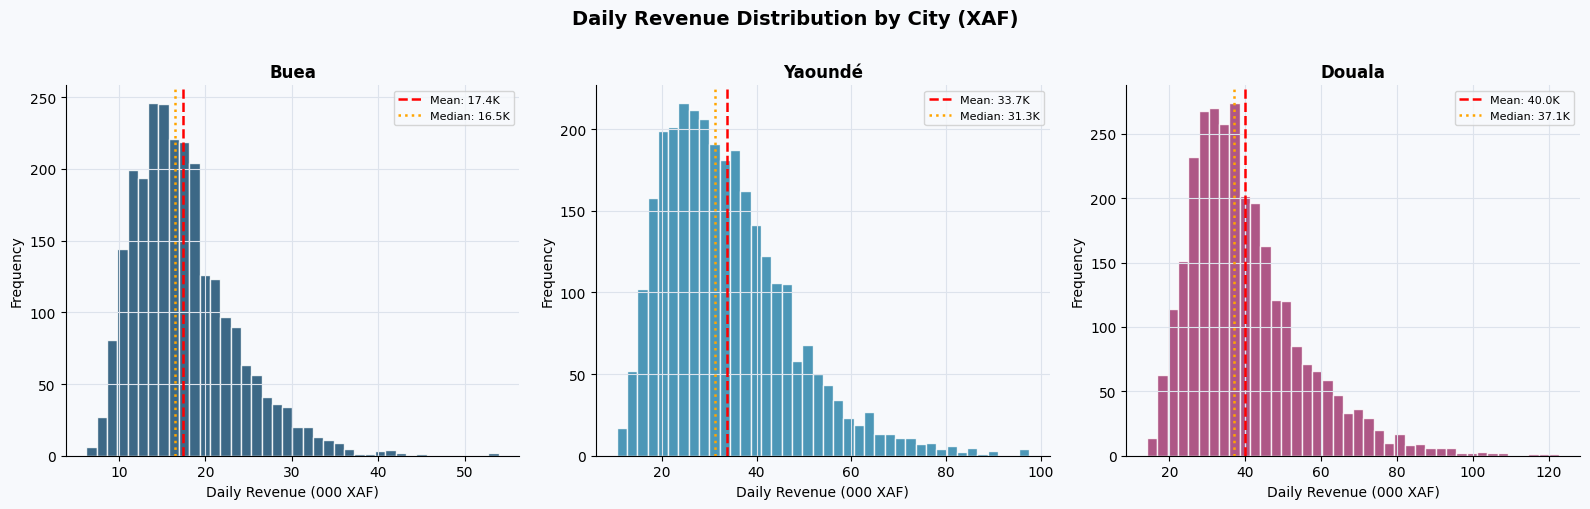

Figure 1 saved ✔


In [5]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — EDA: Revenue Distribution by City                     ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Daily Revenue Distribution by City (XAF)",
             fontsize=14, fontweight="bold", y=1.01)

for ax, city, color in zip(axes, CITY_MARKETS.keys(), PALETTE):
    subset = df[df["city"] == city]["daily_revenue_xaf"] / 1_000
    ax.hist(subset, bins=40, color=color, alpha=0.85, edgecolor="white")
    ax.axvline(subset.mean(),   color="red",    linestyle="--",
               lw=1.8, label=f"Mean: {subset.mean():.1f}K")
    ax.axvline(subset.median(), color="orange", linestyle=":",
               lw=1.8, label=f"Median: {subset.median():.1f}K")
    ax.set_title(city, fontweight="bold", fontsize=12)
    ax.set_xlabel("Daily Revenue (000 XAF)")
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 1 saved ✔")


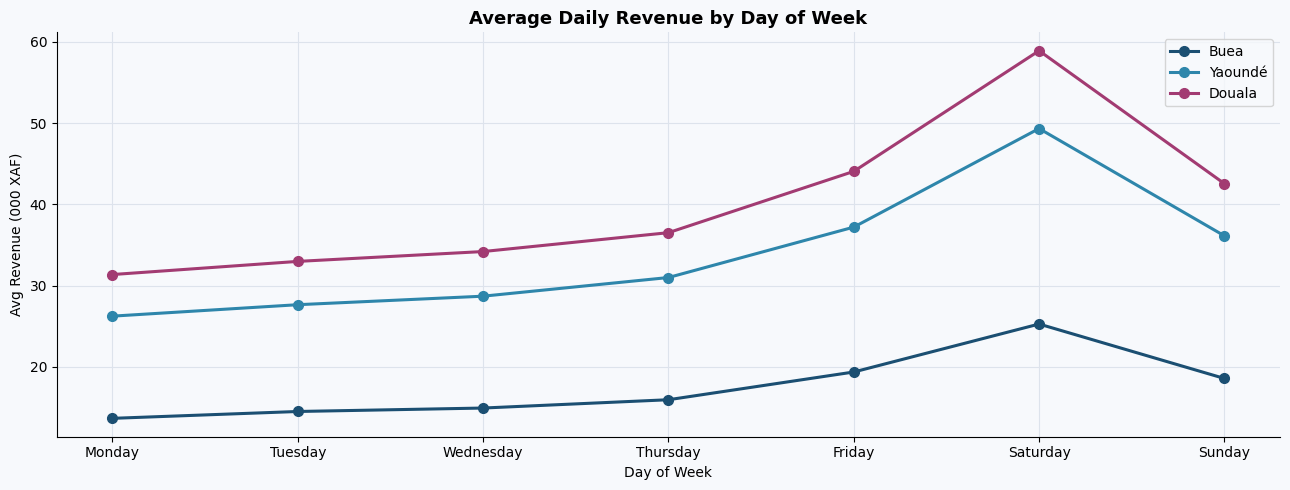

Figure 2 saved ✔


In [6]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — EDA: Day-of-Week Revenue Pattern                      ║
# ╚══════════════════════════════════════════════════════════════════╝

dow_city = (df.groupby(["city","day_of_week"])["daily_revenue_xaf"]
              .mean().reset_index())
dow_city["day_of_week"] = pd.Categorical(
    dow_city["day_of_week"], categories=DOW_ORDER, ordered=True)
dow_city = dow_city.sort_values("day_of_week")

fig, ax = plt.subplots(figsize=(13, 5))
for city, color in zip(CITY_MARKETS.keys(), PALETTE):
    sub = dow_city[dow_city["city"] == city]
    ax.plot(sub["day_of_week"], sub["daily_revenue_xaf"] / 1_000,
            marker="o", label=city, color=color,
            linewidth=2.2, markersize=7)

ax.set_title("Average Daily Revenue by Day of Week",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Avg Revenue (000 XAF)")
ax.legend()
plt.tight_layout()
plt.savefig("plot2_dow.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 2 saved ✔")


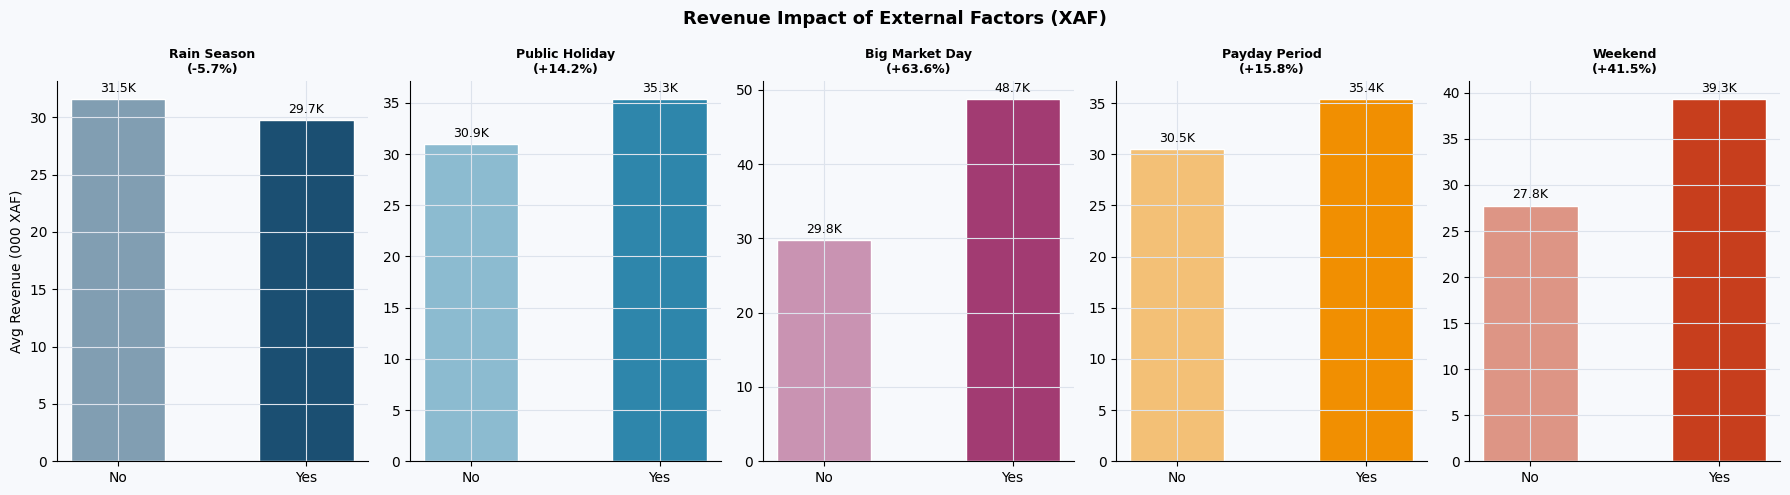

Figure 3 saved ✔


In [7]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — EDA: External Factor Impact                           ║
# ╚══════════════════════════════════════════════════════════════════╝

factors = {
    "Rain Season"    : "rain_season",
    "Public Holiday" : "is_holiday",
    "Big Market Day" : "is_big_market_day",
    "Payday Period"  : "is_payday_period",
    "Weekend"        : "is_weekend",
}

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle("Revenue Impact of External Factors (XAF)",
             fontsize=13, fontweight="bold")

for ax, (label, col), color in zip(axes, factors.items(), PALETTE):
    means = df.groupby(col)["daily_revenue_xaf"].mean() / 1_000
    bars  = ax.bar(["No","Yes"], means.values,
                   color=[color+"88", color],
                   edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%.1fK", padding=3, fontsize=9)
    pct = (means[1] - means[0]) / means[0] * 100
    ax.set_title(f"{label}\n({pct:+.1f}%)", fontsize=9, fontweight="bold")
    ax.set_ylabel("Avg Revenue (000 XAF)" if ax is axes[0] else "")

plt.tight_layout()
plt.savefig("plot3_factors.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 3 saved ✔")


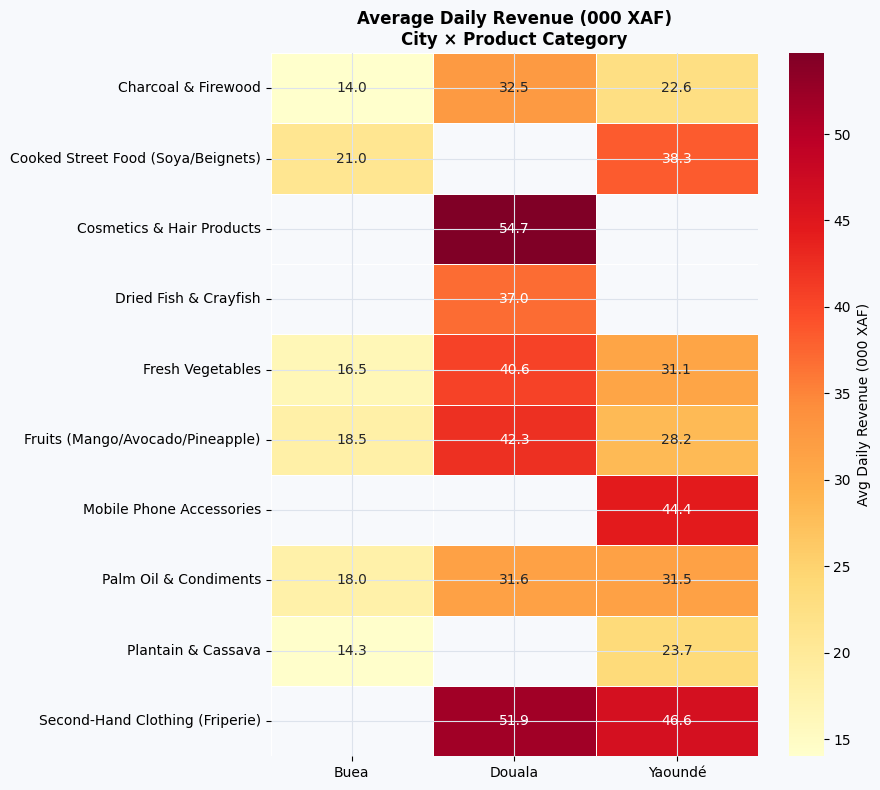

Figure 4 saved ✔


In [8]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 8 — EDA: Category × City Revenue Heatmap                 ║
# ╚══════════════════════════════════════════════════════════════════╝

pivot = (df.pivot_table(values="daily_revenue_xaf",
                        index="product_category",
                        columns="city",
                        aggfunc="mean") / 1_000)

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlOrRd", ax=ax,
            linewidths=0.5,
            cbar_kws={"label": "Avg Daily Revenue (000 XAF)"})
ax.set_title("Average Daily Revenue (000 XAF)\nCity × Product Category",
             fontweight="bold", fontsize=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("plot4_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 4 saved ✔")


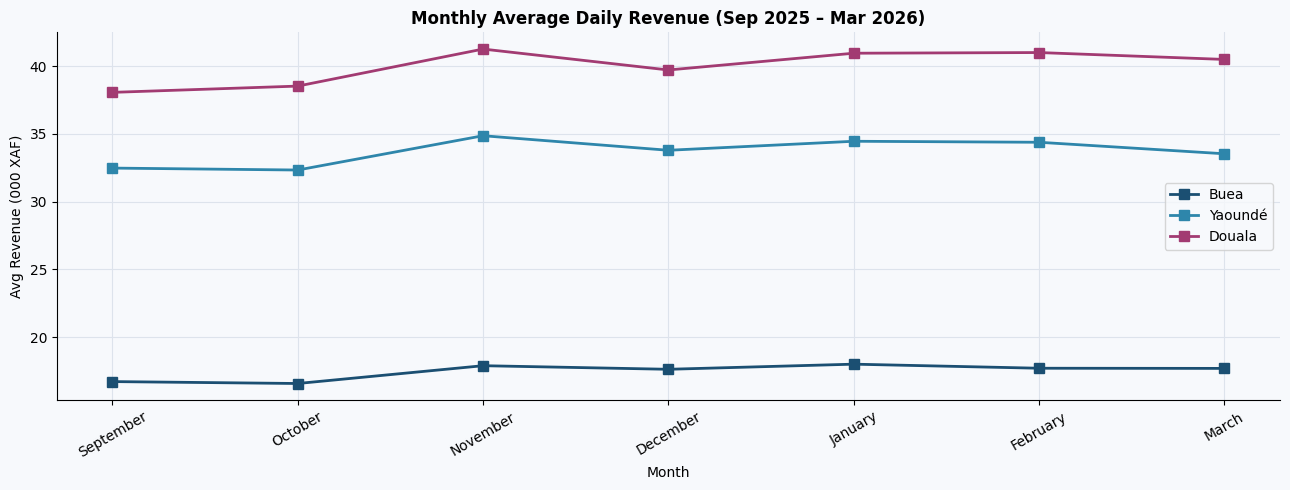

Figure 5 saved ✔


In [9]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 9 — EDA: Monthly Revenue Trend                            ║
# ╚══════════════════════════════════════════════════════════════════╝

monthly = (df.groupby(["city","month"])["daily_revenue_xaf"]
             .mean().reset_index())
monthly["month"] = pd.Categorical(
    monthly["month"], categories=MONTH_ORDER, ordered=True)
monthly = monthly.sort_values("month")

fig, ax = plt.subplots(figsize=(13, 5))
for city, color in zip(CITY_MARKETS.keys(), PALETTE):
    sub = monthly[monthly["city"] == city]
    ax.plot(sub["month"], sub["daily_revenue_xaf"] / 1_000,
            marker="s", label=city, color=color,
            linewidth=2, markersize=7)

ax.set_title("Monthly Average Daily Revenue (Sep 2025 – Mar 2026)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Avg Revenue (000 XAF)")
ax.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("plot5_monthly.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 5 saved ✔")


## Phase 3 — K-Means Clustering

In [10]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Aggregate vendor features for clustering             ║
# ╚══════════════════════════════════════════════════════════════════╝

vendor_agg = df.groupby("vendor_id").agg(
    city             =("city",              "first"),
    product_category =("product_category",  "first"),
    mean_revenue     =("daily_revenue_xaf", "mean"),
    std_revenue      =("daily_revenue_xaf", "std"),
    median_revenue   =("daily_revenue_xaf", "median"),
    mean_transactions=("n_transactions",    "mean"),
).reset_index()

vendor_agg["cv_revenue"] = (
    vendor_agg["std_revenue"] / vendor_agg["mean_revenue"] * 100
)

weekend_rev = (df[df["is_weekend"]==1]
               .groupby("vendor_id")["daily_revenue_xaf"].mean())
weekday_rev = (df[df["is_weekend"]==0]
               .groupby("vendor_id")["daily_revenue_xaf"].mean())
vendor_agg["weekend_premium"] = (
    (weekend_rev / weekday_rev - 1)
    .reindex(vendor_agg["vendor_id"]).values * 100
)

CLUSTER_FEATURES = ["mean_revenue","cv_revenue",
                    "weekend_premium","mean_transactions"]
X_cluster = vendor_agg[CLUSTER_FEATURES].fillna(0)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

print(f"Vendor aggregation: {vendor_agg.shape}")
print()
print(vendor_agg[CLUSTER_FEATURES].describe().round(1))


Vendor aggregation: (40, 9)

       mean_revenue  cv_revenue  weekend_premium  mean_transactions
count          40.0        40.0             40.0               40.0
mean        31026.9        29.8             41.4               16.7
std         11982.1         1.4              3.8                6.6
min         13468.0        26.9             34.0                7.3
25%         20594.1        28.6             39.0               10.8
50%         30387.2        30.0             41.2               16.3
75%         41356.3        30.9             43.6               22.4
max         57819.8        32.5             49.0               31.7


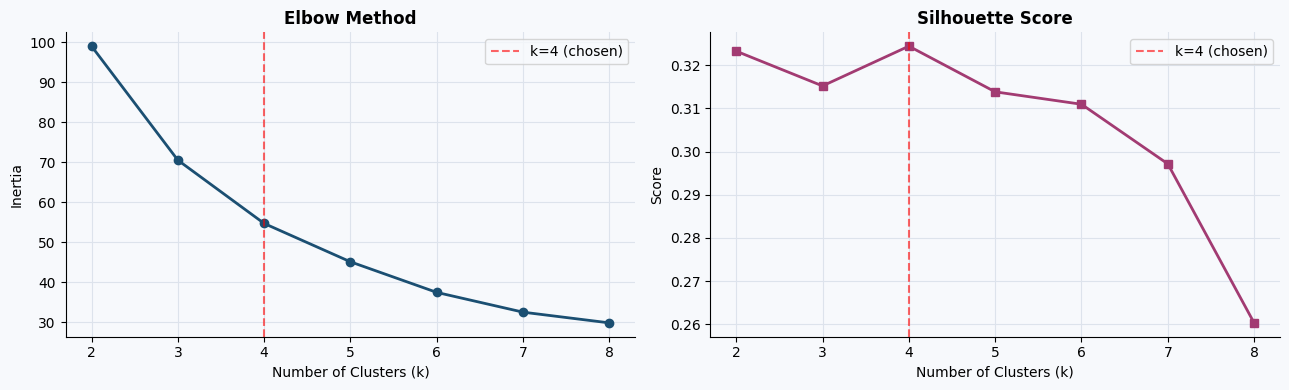

Silhouette scores : [0.323, 0.315, 0.324, 0.314, 0.311, 0.297, 0.26]
Best k            : 4  (silhouette=0.3244)
→ Using k=4 for final clustering


In [11]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Elbow Method & Silhouette Score                      ║
# ╚══════════════════════════════════════════════════════════════════╝

inertias    = []
silhouettes = []
K_RANGE     = range(2, 9)

for k in K_RANGE:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(K_RANGE), inertias, marker="o",
         color=PALETTE[0], linewidth=2)
ax1.axvline(4, color="red", linestyle="--",
            alpha=0.6, label="k=4 (chosen)")
ax1.set_title("Elbow Method", fontweight="bold")
ax1.set_xlabel("Number of Clusters (k)")
ax1.set_ylabel("Inertia")
ax1.legend()

ax2.plot(list(K_RANGE), silhouettes, marker="s",
         color=PALETTE[2], linewidth=2)
ax2.axvline(4, color="red", linestyle="--",
            alpha=0.6, label="k=4 (chosen)")
ax2.set_title("Silhouette Score", fontweight="bold")
ax2.set_xlabel("Number of Clusters (k)")
ax2.set_ylabel("Score")
ax2.legend()

plt.tight_layout()
plt.savefig("plot6_elbow.png", dpi=150, bbox_inches="tight")
plt.show()

best_sil = max(silhouettes)
best_k   = list(K_RANGE)[silhouettes.index(best_sil)]
print(f"Silhouette scores : {[round(s,3) for s in silhouettes]}")
print(f"Best k            : {best_k}  (silhouette={best_sil:.4f})")
print("→ Using k=4 for final clustering")


Cluster profiles:
         mean_revenue  cv_revenue  weekend_premium  mean_transactions  \
cluster                                                                 
0             39554.9        28.2             36.0               21.5   
1             21846.2        31.1             42.7               11.7   
2             42504.0        30.3             43.8               23.1   
3             20889.3        28.7             39.5               11.1   

         n_vendors  
cluster             
0                5  
1               10  
2               14  
3               11  

  Cluster 3: Low-Volume Subsistence  (11 vendors)
  Cluster 2: High-Volume Thriving  (14 vendors)
  Cluster 1: Volatile Opportunists  (10 vendors)
  Cluster 0: Stable Mid-tier  (5 vendors)


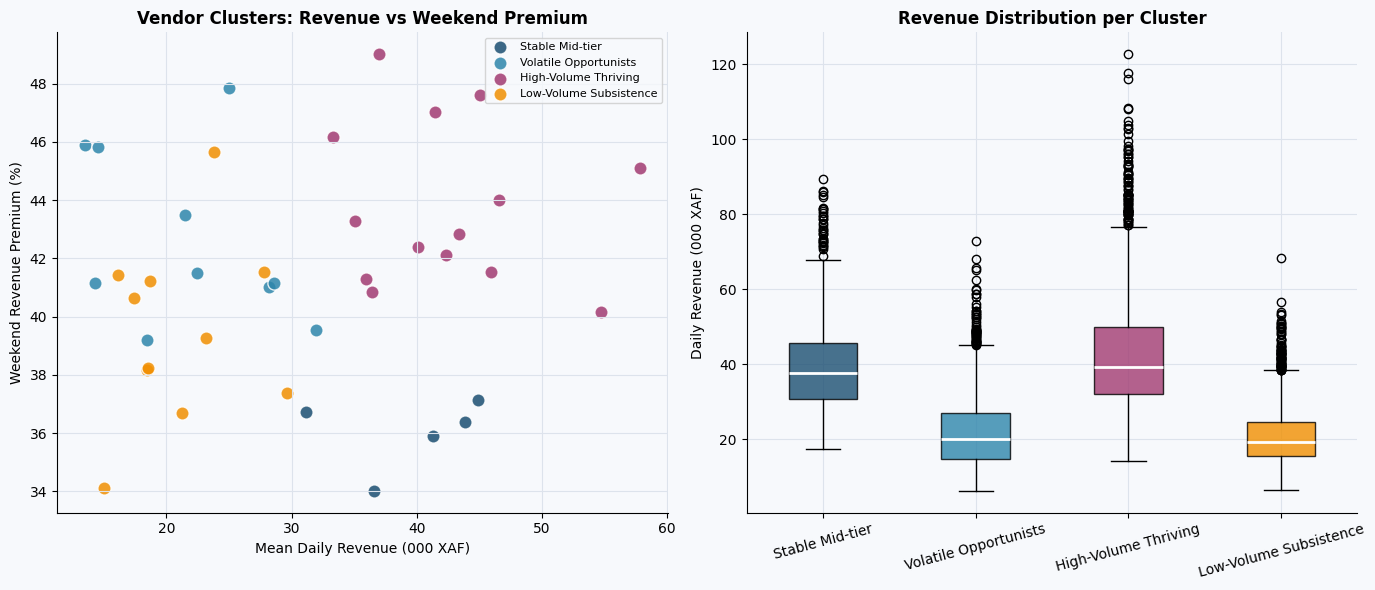

Figure 7 saved ✔


In [12]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Final k=4 Clustering + Visualisation                 ║
# ╚══════════════════════════════════════════════════════════════════╝

km_final = KMeans(n_clusters=4, random_state=42, n_init=10)
vendor_agg["cluster"] = km_final.fit_predict(X_scaled)

# Merge cluster back to main dataframe
df = df.merge(vendor_agg[["vendor_id","cluster"]],
              on="vendor_id", how="left")

# Cluster profile summary
cluster_profile = (vendor_agg.groupby("cluster").agg(
    mean_revenue     =("mean_revenue",      "mean"),
    cv_revenue       =("cv_revenue",        "mean"),
    weekend_premium  =("weekend_premium",   "mean"),
    mean_transactions=("mean_transactions", "mean"),
    n_vendors        =("mean_revenue",      "count"),
).round(1))

print("Cluster profiles:")
print(cluster_profile)

# Assign human-readable labels
CLUSTER_LABELS = {
    cluster_profile["mean_revenue"].idxmin() : "Low-Volume Subsistence",
    cluster_profile["mean_revenue"].idxmax() : "High-Volume Thriving",
    cluster_profile["cv_revenue"].idxmax()   : "Volatile Opportunists",
}
remaining = [i for i in cluster_profile.index
             if i not in CLUSTER_LABELS]
CLUSTER_LABELS[remaining[0]] = "Stable Mid-tier"

vendor_agg["cluster_label"] = vendor_agg["cluster"].map(CLUSTER_LABELS)
df["cluster_label"]         = df["cluster"].map(CLUSTER_LABELS)

print()
for k, v in CLUSTER_LABELS.items():
    n = (vendor_agg["cluster"] == k).sum()
    print(f"  Cluster {k}: {v}  ({n} vendors)")

# ── Visualise ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
for cl in range(4):
    sub   = vendor_agg[vendor_agg["cluster"] == cl]
    label = CLUSTER_LABELS.get(cl, f"Cluster {cl}")
    ax.scatter(sub["mean_revenue"] / 1_000, sub["weekend_premium"],
               color=PALETTE[cl], label=label,
               s=90, alpha=0.85, edgecolors="white")
ax.set_xlabel("Mean Daily Revenue (000 XAF)")
ax.set_ylabel("Weekend Revenue Premium (%)")
ax.set_title("Vendor Clusters: Revenue vs Weekend Premium",
             fontweight="bold")
ax.legend(fontsize=8)

ax2 = axes[1]
cluster_order = [CLUSTER_LABELS[k] for k in sorted(CLUSTER_LABELS.keys())]
bp_data = [
    df[df["cluster_label"] == cl]["daily_revenue_xaf"].values / 1_000
    for cl in cluster_order
]
bp = ax2.boxplot(bp_data, tick_labels=cluster_order,
                 patch_artist=True,
                 medianprops=dict(color="white", linewidth=2))
for patch, color in zip(bp["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax2.set_ylabel("Daily Revenue (000 XAF)")
ax2.set_title("Revenue Distribution per Cluster", fontweight="bold")
plt.xticks(rotation=15)

plt.tight_layout()
plt.savefig("plot7_clusters.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 7 saved ✔")


## Phase 4 — Association Rule Mining

In [13]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Build Baskets & Run Apriori                          ║
# ╚══════════════════════════════════════════════════════════════════╝

# Revenue tier labels
q25 = df["daily_revenue_xaf"].quantile(0.25)
q75 = df["daily_revenue_xaf"].quantile(0.75)

def rev_tier(v):
    if v < q25:   return "Revenue:Low"
    elif v > q75: return "Revenue:High"
    else:         return "Revenue:Medium"

df["rev_tier"] = df["daily_revenue_xaf"].apply(rev_tier)

# Basket builder
def make_basket(row):
    items = [
        f"Cat:{row['product_category']}",
        f"Day:{row['day_of_week']}",
        f"City:{row['city']}",
        row["rev_tier"],
    ]
    if row["is_weekend"]:        items.append("Context:Weekend")
    if row["is_holiday"]:        items.append("Context:Holiday")
    if row["is_big_market_day"]: items.append("Context:BigMarketDay")
    if row["is_payday_period"]:  items.append("Context:PaydayPeriod")
    if row["rain_season"]:       items.append("Context:RainSeason")
    return items

baskets = df.apply(make_basket, axis=1).tolist()

# Encode and run Apriori
te        = TransactionEncoder()
te_array  = te.fit_transform(baskets)
basket_df = pd.DataFrame(te_array, columns=te.columns_)

frequent_itemsets = apriori(basket_df, min_support=0.05,
                            use_colnames=True, max_len=4)
rules = association_rules(frequent_itemsets,
                          metric="lift", min_threshold=1.5)
rules = rules.sort_values("lift", ascending=False)

# Filter to high-revenue rules
high_rev_rules = (
    rules[rules["consequents"].apply(lambda x: "Revenue:High" in x)]
    .sort_values("lift", ascending=False)
    .head(15)
    .copy()
)
high_rev_rules["rule_label"] = high_rev_rules["antecedents"].apply(
    lambda x: " + ".join(sorted(str(i).split(":")[1] for i in x))
)

print(f"Total baskets          : {len(baskets):,}")
print(f"Frequent itemsets      : {len(frequent_itemsets)}")
print(f"Rules (lift ≥ 1.5)     : {len(rules)}")
print(f"→ High revenue rules   : {len(high_rev_rules)}")
print()
print("Top 5 rules → Revenue:High:")
print(high_rev_rules[["rule_label","support","confidence","lift"]]
      .head(5).to_string(index=False))


Total baskets          : 8,480
Frequent itemsets      : 97
Rules (lift ≥ 1.5)     : 74
→ High revenue rules   : 12

Top 5 rules → Revenue:High:
                     rule_label  support  confidence     lift
                       Saturday 0.078184    0.552500 4.522394
                        Weekend 0.078184    0.276250 3.533333
Second-Hand Clothing (Friperie) 0.054835    0.731132 2.924528
               Douala + Weekend 0.069811    0.704762 2.819048
             Saturday + Weekend 0.078184    0.552500 2.210000


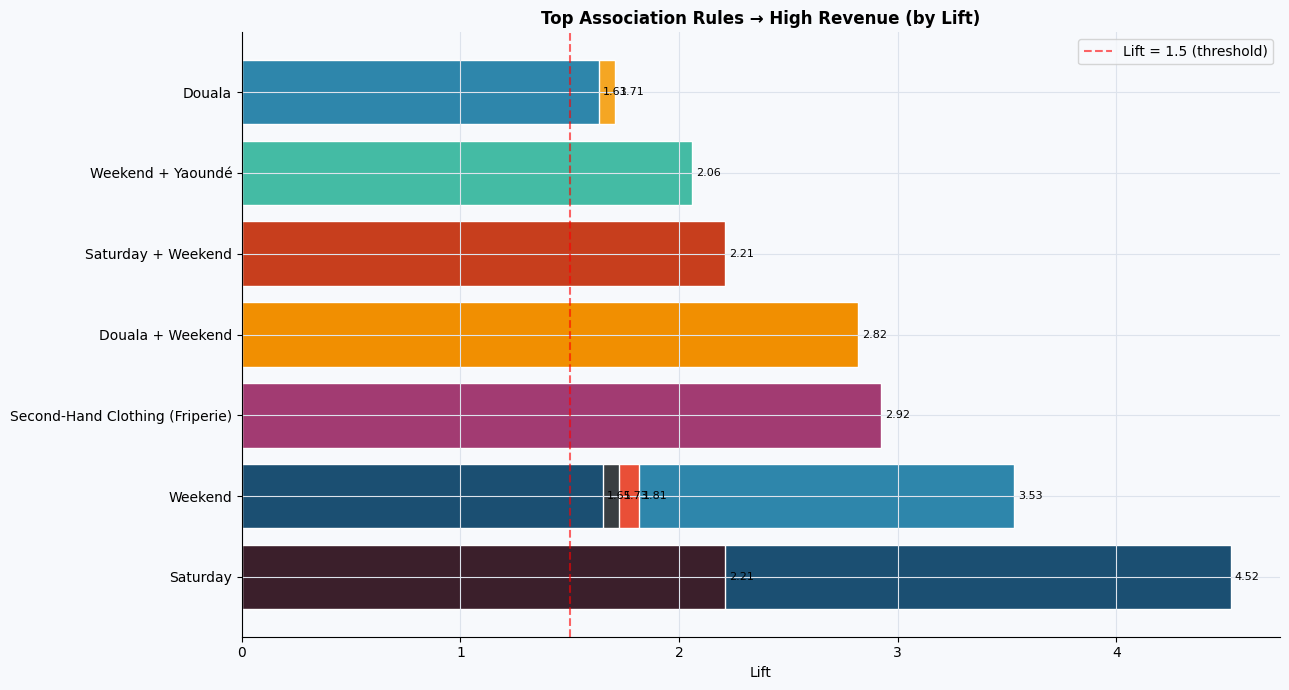

Figure 8 saved ✔


In [14]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Plot Association Rules                               ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, ax = plt.subplots(figsize=(13, 7))

colors_rules = [PALETTE[i % len(PALETTE)]
                for i in range(len(high_rev_rules))]
bars = ax.barh(high_rev_rules["rule_label"],
               high_rev_rules["lift"],
               color=colors_rules, edgecolor="white")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
ax.axvline(1.5, color="red", linestyle="--", alpha=0.6,
           label="Lift = 1.5 (threshold)")
ax.set_xlabel("Lift")
ax.set_title("Top Association Rules → High Revenue (by Lift)",
             fontweight="bold", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("plot8_rules.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 8 saved ✔")


## Phase 5 — Six-Algorithm Regression Comparison

In [15]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Feature Engineering & Train/Test Split               ║
# ╚══════════════════════════════════════════════════════════════════╝

model_df = df.copy()

le = LabelEncoder()
for col in ["city","market","product_category","day_of_week","month"]:
    model_df[col + "_enc"] = le.fit_transform(model_df[col])

FEATURES = [
    "city_enc", "market_enc", "product_category_enc",
    "day_of_week_enc", "month_enc", "month_num",
    "is_weekend", "is_holiday", "rain_season",
    "is_big_market_day", "is_payday_period",
    "n_transactions", "cluster",
]
TARGET = "daily_revenue_xaf"

X = model_df[FEATURES]
y = model_df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print(f"Training set : {X_train.shape[0]:,} records")
print(f"Test set     : {X_test.shape[0]:,} records")
print(f"Features     : {len(FEATURES)}")
for f in FEATURES:
    print(f"  • {f}")


Training set : 6,784 records
Test set     : 1,696 records
Features     : 13
  • city_enc
  • market_enc
  • product_category_enc
  • day_of_week_enc
  • month_enc
  • month_num
  • is_weekend
  • is_holiday
  • rain_season
  • is_big_market_day
  • is_payday_period
  • n_transactions
  • cluster


In [16]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 16 — Train & Evaluate All Six Algorithms                  ║
# ╚══════════════════════════════════════════════════════════════════╝

ALGORITHMS = {
    "Linear Regression"    : LinearRegression(),
    "Ridge Regression"     : Ridge(alpha=1.0),
    "Decision Tree"        : DecisionTreeRegressor(
                                max_depth=12, random_state=42),
    "K-Nearest Neighbours" : KNeighborsRegressor(n_neighbors=7),
    "Gradient Boosting"    : GradientBoostingRegressor(
                                n_estimators=150, max_depth=5,
                                random_state=42),
    "Random Forest"        : RandomForestRegressor(
                                n_estimators=200, max_depth=18,
                                min_samples_leaf=3,
                                random_state=42, n_jobs=-1),
}

results = []    # stores dicts with all metrics
y_preds = {}    # stores predictions per algorithm

hdr = (f"{'Algorithm':<25} {'R²':>7} {'MAE (XAF)':>11} "
       f"{'RMSE':>9} {'MAPE%':>7} {'CV R²':>7} {'Sec':>5}")
print(hdr)
print("─" * len(hdr))

for name, model in ALGORITHMS.items():
    t0    = time.time()
    model.fit(X_train, y_train)
    secs  = time.time() - t0

    y_pred = model.predict(X_test)
    y_preds[name] = y_pred

    r2   = r2_score(y_test, y_pred)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    mape = float(np.mean(np.abs((y_test - y_pred) / y_test)) * 100)
    cv   = float(cross_val_score(
                    model, X, y, cv=5, scoring="r2").mean())

    results.append({
        "Algorithm": name,
        "R2": r2, "MAE": mae, "RMSE": rmse,
        "MAPE": mape, "CV_R2": cv, "Time": secs,
        "model": model,
    })
    print(f"{name:<25} {r2:>7.4f} {mae:>11,.0f} "
          f"{rmse:>9,.0f} {mape:>7.2f} {cv:>7.4f} {secs:>5.2f}")

best = max(results, key=lambda r: r["R2"])
print()
print(f"★  Best model : {best['Algorithm']}")
print(f"   R²         : {best['R2']:.4f}")
print(f"   MAE        : {best['MAE']:,.0f} XAF")
print(f"   MAPE       : {best['MAPE']:.2f}%")
print(f"   CV R²      : {best['CV_R2']:.4f}")


Algorithm                      R²   MAE (XAF)      RMSE   MAPE%   CV R²   Sec
─────────────────────────────────────────────────────────────────────────────
Linear Regression          0.9503       2,754     3,448   11.14  0.8475  0.04
Ridge Regression           0.9503       2,754     3,448   11.14  0.8475  0.02
Decision Tree              0.9382       2,962     3,845   11.27  0.7871  0.07
K-Nearest Neighbours       0.9512       2,656     3,416   10.13  0.8435  0.15
Gradient Boosting          0.9625       2,362     2,995    8.93  0.8717  5.40
Random Forest              0.9576       2,463     3,186    9.37  0.8560  4.20

★  Best model : Gradient Boosting
   R²         : 0.9625
   MAE        : 2,362 XAF
   MAPE       : 8.93%
   CV R²      : 0.8717


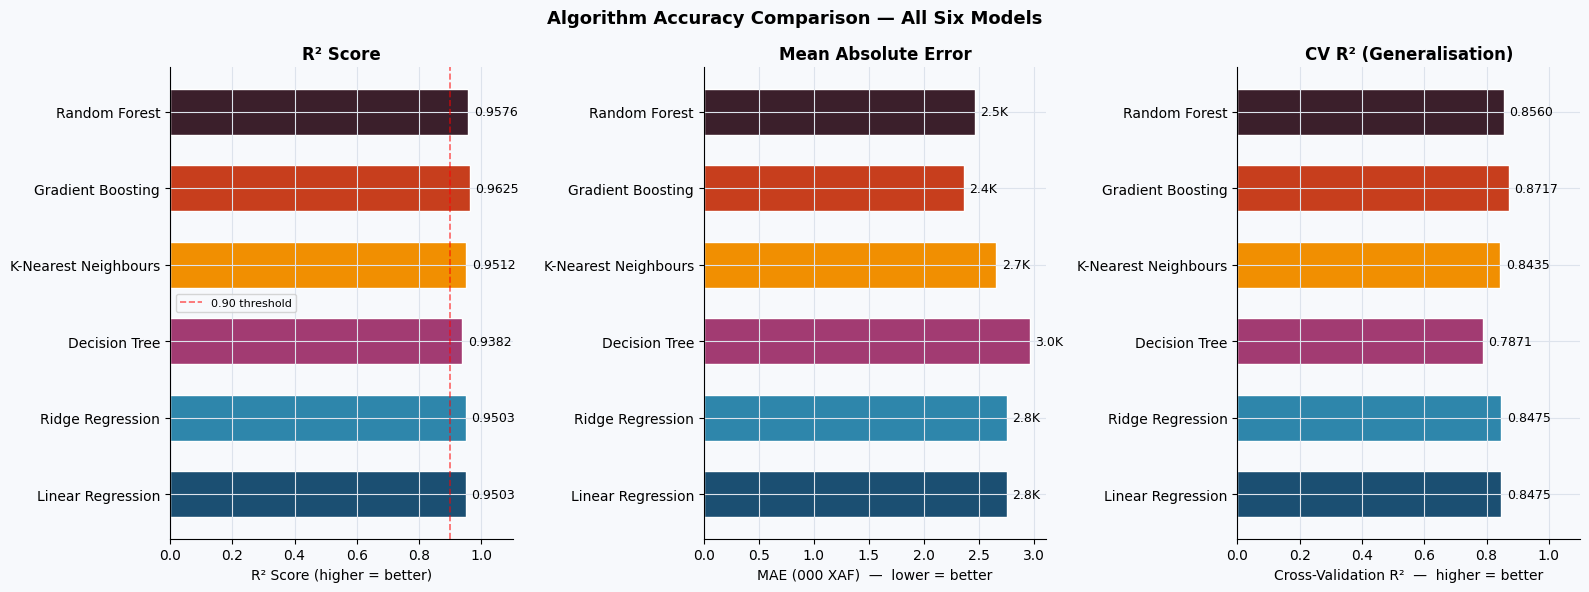

Figure 9 saved ✔


In [17]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 17 — Accuracy Bar Chart Comparison (R², MAE, CV R²)       ║
# ╚══════════════════════════════════════════════════════════════════╝

names  = [r["Algorithm"] for r in results]
colors = PALETTE[:len(results)]

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Algorithm Accuracy Comparison — All Six Models",
             fontsize=13, fontweight="bold")

# R²
ax = axes[0]
r2_vals = [r["R2"] for r in results]
bars    = ax.barh(names, r2_vals, color=colors,
                  edgecolor="white", height=0.6)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.axvline(0.90, color="red", linestyle="--",
           lw=1.2, alpha=0.6, label="0.90 threshold")
ax.set_xlabel("R² Score (higher = better)")
ax.set_title("R² Score", fontweight="bold")
ax.set_xlim(0, 1.10)
ax.legend(fontsize=8)

# MAE
ax = axes[1]
mae_vals = [r["MAE"] / 1_000 for r in results]
bars     = ax.barh(names, mae_vals, color=colors,
                   edgecolor="white", height=0.6)
ax.bar_label(bars, fmt="%.1fK", padding=4, fontsize=9)
ax.set_xlabel("MAE (000 XAF)  —  lower = better")
ax.set_title("Mean Absolute Error", fontweight="bold")

# CV R²
ax = axes[2]
cv_vals = [r["CV_R2"] for r in results]
bars    = ax.barh(names, cv_vals, color=colors,
                  edgecolor="white", height=0.6)
ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=9)
ax.set_xlabel("Cross-Validation R²  —  higher = better")
ax.set_title("CV R² (Generalisation)", fontweight="bold")
ax.set_xlim(0, 1.10)

plt.tight_layout()
plt.savefig("plot_comparison_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 9 saved ✔")


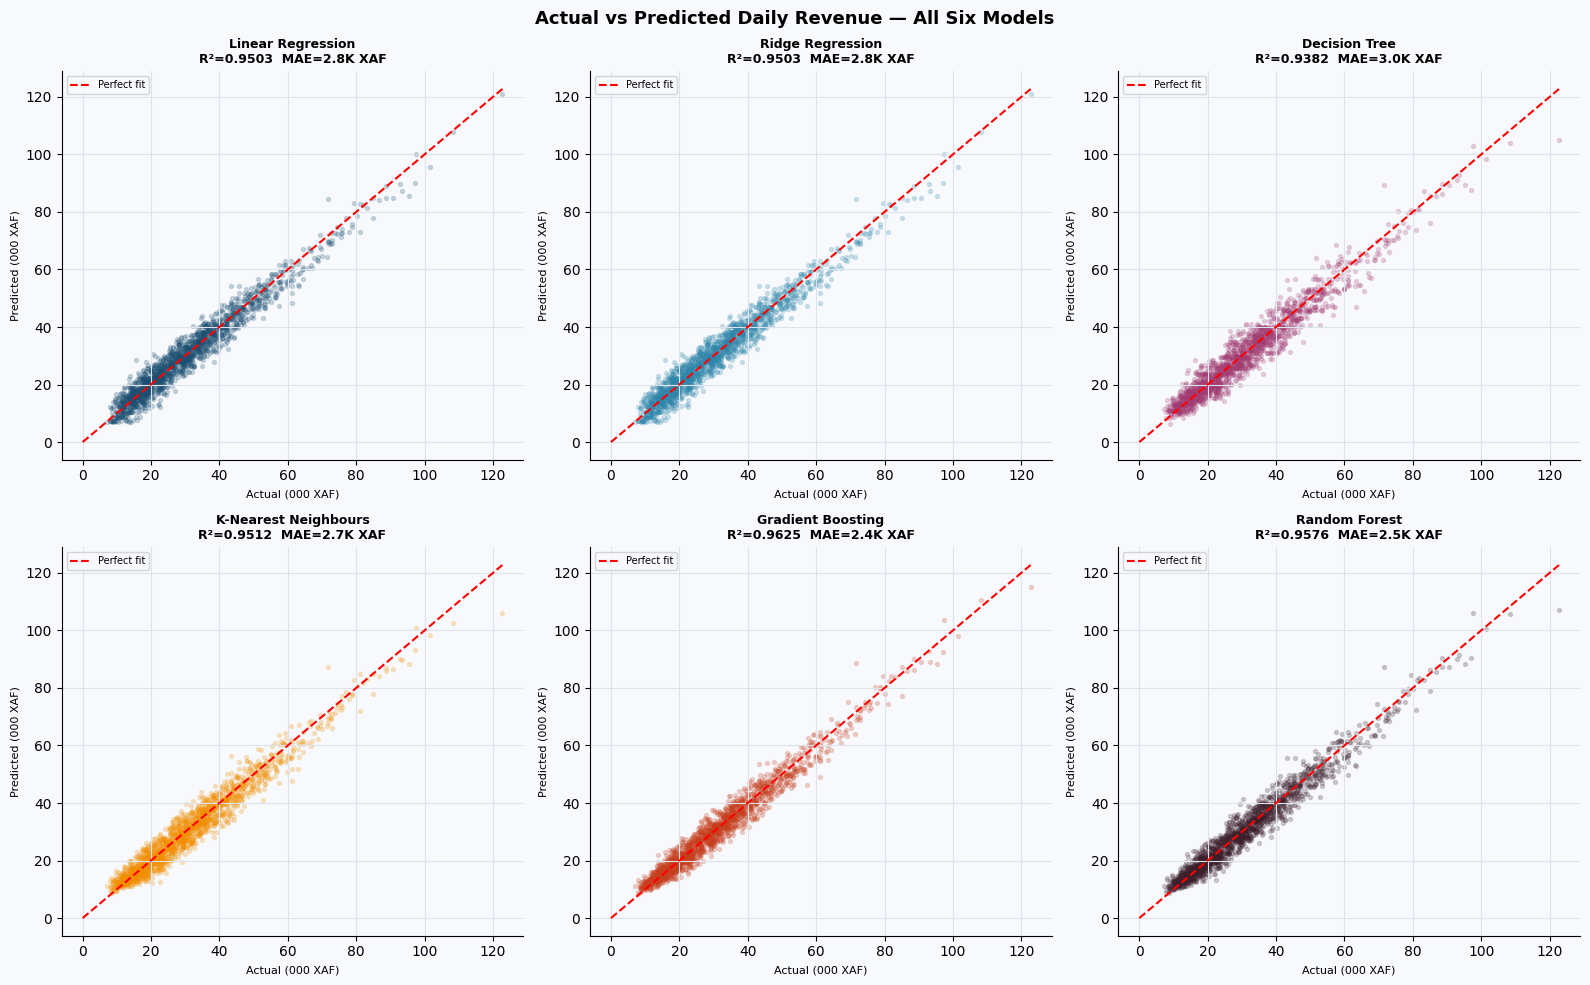

Figure 10 saved ✔


In [18]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 18 — Actual vs Predicted  (all 6 models)                  ║
# ╚══════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Actual vs Predicted Daily Revenue — All Six Models",
             fontsize=13, fontweight="bold")

for ax, r, color in zip(axes.flatten(), results, PALETTE):
    yp   = y_preds[r["Algorithm"]]
    ax.scatter(y_test / 1_000, yp / 1_000,
               alpha=0.20, color=color, s=8)
    lims = [0, max(float(y_test.max()), float(yp.max())) / 1_000]
    ax.plot(lims, lims, "r--", lw=1.5, label="Perfect fit")
    ax.set_title(
        f"{r['Algorithm']}\nR²={r['R2']:.4f}  "
        f"MAE={r['MAE']/1000:.1f}K XAF",
        fontsize=9, fontweight="bold")
    ax.set_xlabel("Actual (000 XAF)",     fontsize=8)
    ax.set_ylabel("Predicted (000 XAF)",  fontsize=8)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig("plot_actual_vs_pred_all.png", dpi=150,
            bbox_inches="tight")
plt.show()
print("Figure 10 saved ✔")


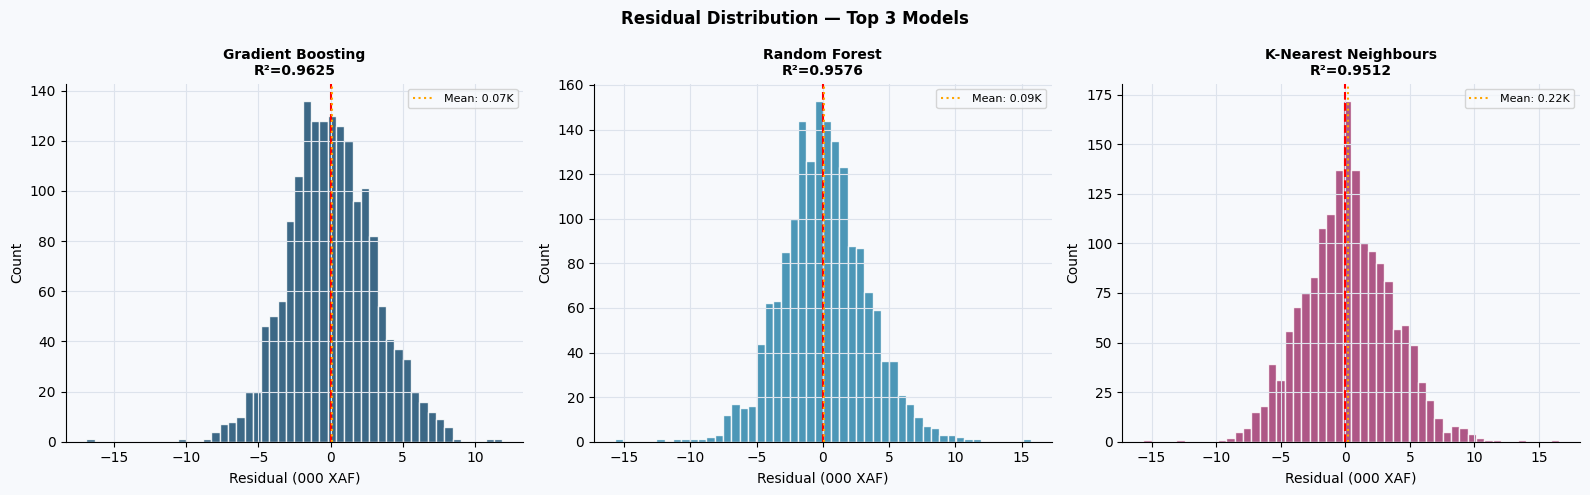

Figure 11 saved ✔


In [19]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 19 — Residual Distributions (top 3 models)               ║
# ╚══════════════════════════════════════════════════════════════════╝

top3 = sorted(results, key=lambda r: r["R2"], reverse=True)[:3]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Residual Distribution — Top 3 Models",
             fontsize=12, fontweight="bold")

for ax, r, color in zip(axes, top3, PALETTE):
    res = (y_test - y_preds[r["Algorithm"]]) / 1_000
    ax.hist(res, bins=50, color=color,
            edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linestyle="--", lw=1.5)
    ax.axvline(float(res.mean()), color="orange", linestyle=":",
               lw=1.5, label=f"Mean: {float(res.mean()):.2f}K")
    ax.set_title(f"{r['Algorithm']}\nR²={r['R2']:.4f}",
                 fontweight="bold", fontsize=10)
    ax.set_xlabel("Residual (000 XAF)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("plot_residuals_top3.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 11 saved ✔")


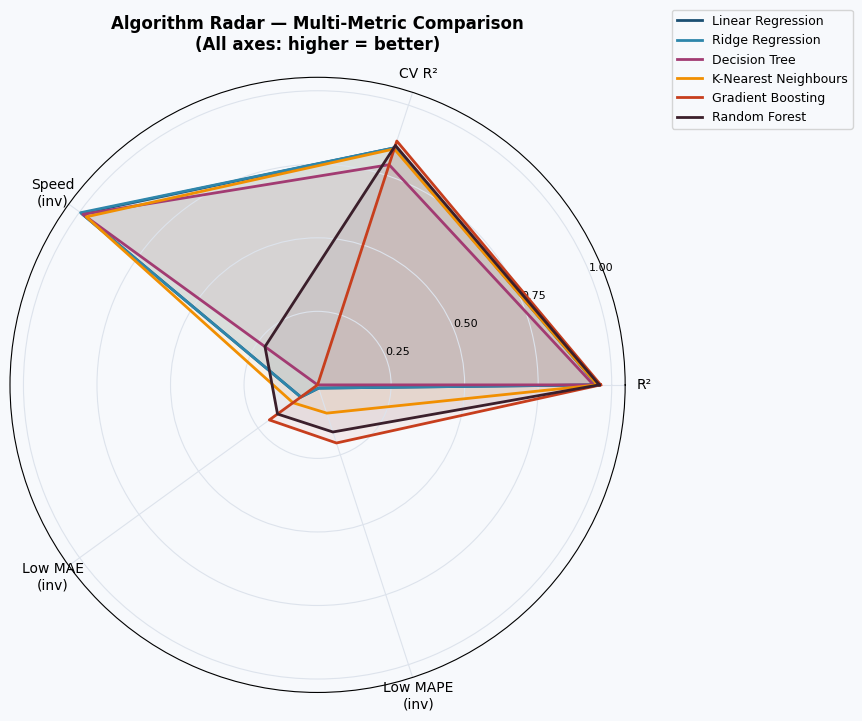

Figure 12 saved ✔


In [20]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 20 — Radar Chart: Multi-Metric Comparison                 ║
# ╚══════════════════════════════════════════════════════════════════╝

cats   = ["R²", "CV R²", "Speed\n(inv)", "Low MAE\n(inv)", "Low MAPE\n(inv)"]
N      = len(cats)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]   # close the polygon

max_time = max(r["Time"] for r in results)
max_mae  = max(r["MAE"]  for r in results)
max_mape = max(r["MAPE"] for r in results)

def radar_vals(r):
    return [
        r["R2"],
        max(0.0, r["CV_R2"]),
        1 - r["Time"] / max_time,
        1 - r["MAE"]  / max_mae,
        1 - r["MAPE"] / max_mape,
    ]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for r, color in zip(results, PALETTE):
    v  = radar_vals(r)
    v += [v[0]]   # close polygon
    ax.plot(angles, v, color=color, linewidth=2, label=r["Algorithm"])
    ax.fill(angles, v, color=color, alpha=0.07)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=10)
ax.set_yticks([0.25, 0.50, 0.75, 1.00])
ax.set_yticklabels(["0.25","0.50","0.75","1.00"], fontsize=8)
ax.set_title("Algorithm Radar — Multi-Metric Comparison\n"
             "(All axes: higher = better)",
             fontweight="bold", fontsize=12, pad=20)
ax.legend(loc="upper right",
          bbox_to_anchor=(1.38, 1.12), fontsize=9)
plt.tight_layout()
plt.savefig("plot_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 12 saved ✔")


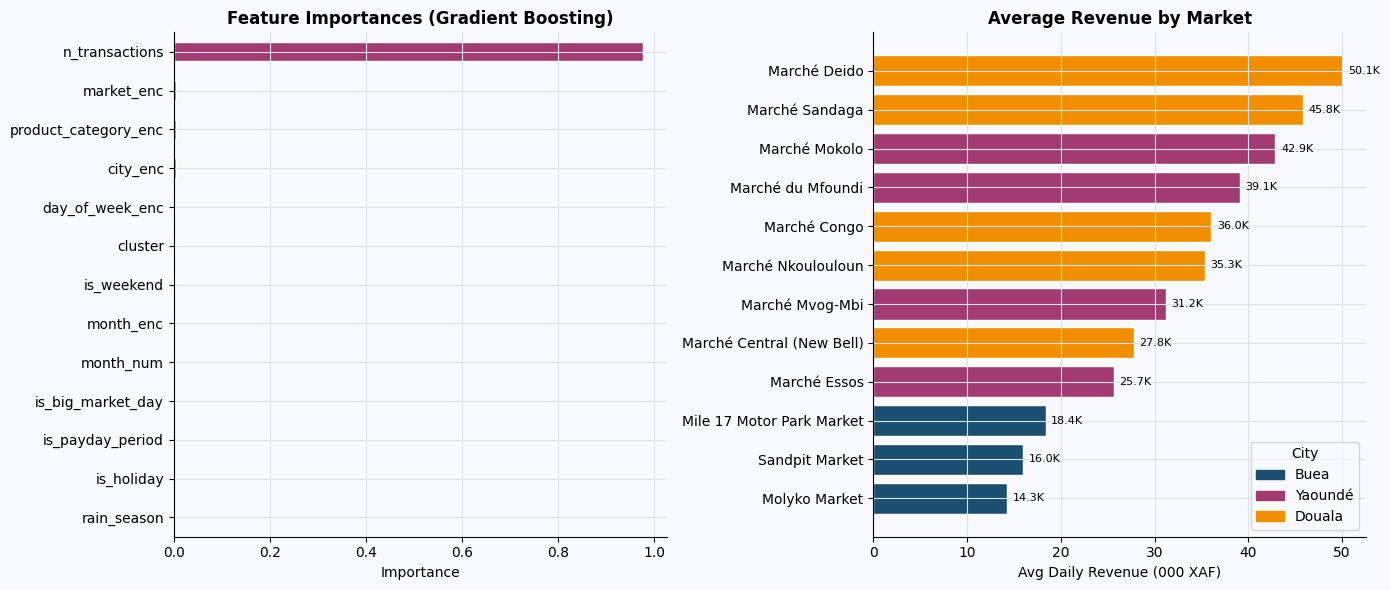

Figure 13 saved ✔


In [21]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 21 — Feature Importances + Market Revenue Chart           ║
# ╚══════════════════════════════════════════════════════════════════╝

best_model = next(r["model"] for r in results
                  if r["Algorithm"] == "Gradient Boosting")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature importances
ax = axes[0]
importances = (pd.Series(best_model.feature_importances_,
                         index=FEATURES)
               .sort_values(ascending=True))
bar_colors  = [PALETTE[2] if v > importances.median() else PALETTE[0]
               for v in importances]
importances.plot(kind="barh", ax=ax,
                 color=bar_colors, edgecolor="white")
ax.set_title("Feature Importances (Gradient Boosting)",
             fontweight="bold")
ax.set_xlabel("Importance")

# Average revenue by market
ax2 = axes[1]
city_colors = {
    "Buea":    PALETTE[0],
    "Yaoundé": PALETTE[2],
    "Douala":  PALETTE[3],
}
market_rev = (df.groupby(["city","market"])["daily_revenue_xaf"]
              .mean().reset_index()
              .sort_values("daily_revenue_xaf", ascending=True))
m_colors = [city_colors[c] for c in market_rev["city"]]
bars = ax2.barh(market_rev["market"],
                market_rev["daily_revenue_xaf"] / 1_000,
                color=m_colors, edgecolor="white")
ax2.bar_label(bars, fmt="%.1fK", padding=4, fontsize=8)
ax2.set_xlabel("Avg Daily Revenue (000 XAF)")
ax2.set_title("Average Revenue by Market", fontweight="bold")
patches = [mpatches.Patch(color=v, label=k)
           for k, v in city_colors.items()]
ax2.legend(handles=patches, title="City")

plt.tight_layout()
plt.savefig("plot10_markets.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 13 saved ✔")


In [22]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  CELL 22 — FINAL PROJECT SUMMARY                                ║
# ╚══════════════════════════════════════════════════════════════════╝

best_r = max(results, key=lambda r: r["R2"])

print("=" * 60)
print("  PROJECT SUMMARY — CAMEROON VENDOR MINING")
print("  Student   : NYUYDZE BANVEN ERIC JUNIOR | CT23A135")
print("  Supervisor: Mr. Kometa Denis")
print("=" * 60)
print(f"  Dataset       : {df.shape[0]:,} records, "
      f"{df.vendor_id.nunique()} vendors, "
      f"12 markets, 3 cities")
print(f"  Date range    : Sep 2025 – Mar 2026 (7 months)")
print(f"  Revenue range : {df.daily_revenue_xaf.min()/1000:.1f}K – "
      f"{df.daily_revenue_xaf.max()/1000:.1f}K XAF")
print()
print(f"  Clusters (k=4): silhouette = {best_sil:.4f}")
print(f"  Assoc. rules  : {len(rules)} total  |  "
      f"{len(high_rev_rules)} → high revenue")
print()
print(f"  {'Algorithm':<25} {'R²':>7} {'MAE (XAF)':>11} "
      f"{'MAPE%':>7} {'CV R²':>7}")
print(f"  {'─'*59}")
for r in sorted(results, key=lambda x: x["R2"], reverse=True):
    star = "  ★ BEST" if r["Algorithm"] == best_r["Algorithm"] else ""
    print(f"  {r['Algorithm']:<25} {r['R2']:>7.4f} "
          f"{r['MAE']:>11,.0f} {r['MAPE']:>7.2f} "
          f"{r['CV_R2']:>7.4f}{star}")
print()

all_plots = [
    "plot1_distribution.png", "plot2_dow.png",
    "plot3_factors.png",       "plot4_heatmap.png",
    "plot5_monthly.png",       "plot6_elbow.png",
    "plot7_clusters.png",      "plot8_rules.png",
    "plot_comparison_bar.png", "plot_actual_vs_pred_all.png",
    "plot_residuals_top3.png", "plot_radar.png",
    "plot10_markets.png",
]
missing = [p for p in all_plots if not os.path.exists(p)]
print(f"  Plots saved : {len(all_plots)-len(missing)}/{len(all_plots)} "
      + ("✔" if not missing else f"✘ missing: {missing}"))
print(f"  Dataset CSV : "
      + ("cameroon_vendor_data.csv ✔"
         if os.path.exists("cameroon_vendor_data.csv") else "✘ MISSING"))
print("=" * 60)


  PROJECT SUMMARY — CAMEROON VENDOR MINING
  Student   : NYUYDZE BANVEN ERIC JUNIOR | CT23A135
  Supervisor: Mr. Kometa Denis
  Dataset       : 8,480 records, 40 vendors, 12 markets, 3 cities
  Date range    : Sep 2025 – Mar 2026 (7 months)
  Revenue range : 6.2K – 122.8K XAF

  Clusters (k=4): silhouette = 0.3244
  Assoc. rules  : 74 total  |  12 → high revenue

  Algorithm                      R²   MAE (XAF)   MAPE%   CV R²
  ───────────────────────────────────────────────────────────
  Gradient Boosting          0.9625       2,362    8.93  0.8717  ★ BEST
  Random Forest              0.9576       2,463    9.37  0.8560
  K-Nearest Neighbours       0.9512       2,656   10.13  0.8435
  Ridge Regression           0.9503       2,754   11.14  0.8475
  Linear Regression          0.9503       2,754   11.14  0.8475
  Decision Tree              0.9382       2,962   11.27  0.7871

  Plots saved : 13/13 ✔
  Dataset CSV : cameroon_vendor_data.csv ✔
